# Synthetic Signal Generation + OLS Analysis

## Generative model

$$y_i(s) = x_i(s) + e_i(s), \qquad x_i(s) = A_i\,\phi\!\left(\frac{s-\mu}{bw}\right)$$

where $e_i(s)$ is Gaussian-smoothed noise.  
We use the **unnormalized** Gaussian bump throughout, so $A_i$ controls peak height directly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

np.random.seed(42)

# Global parameters
n_instances    = 1000   # number of subjects
n_pixels       = 512    # length of 1-D "image"
s              = np.arange(n_pixels)
mu             = n_pixels // 2   # bump centre  (pixel 256)
bw_signal      = 20              # bump width (SD of Gaussian shape)
noise_kernel_sd = 5              # spatial smoothness of noise
sigma_A        = 2.0             # SD of amplitude distribution

## 1 · Gaussian signal shapes

$$\phi_{\text{unnorm}}(s) = \exp\!\left(-\frac{(s-\mu)^2}{2\,bw^2}\right)$$

Peak is always 1; $A_i$ scales the height directly.


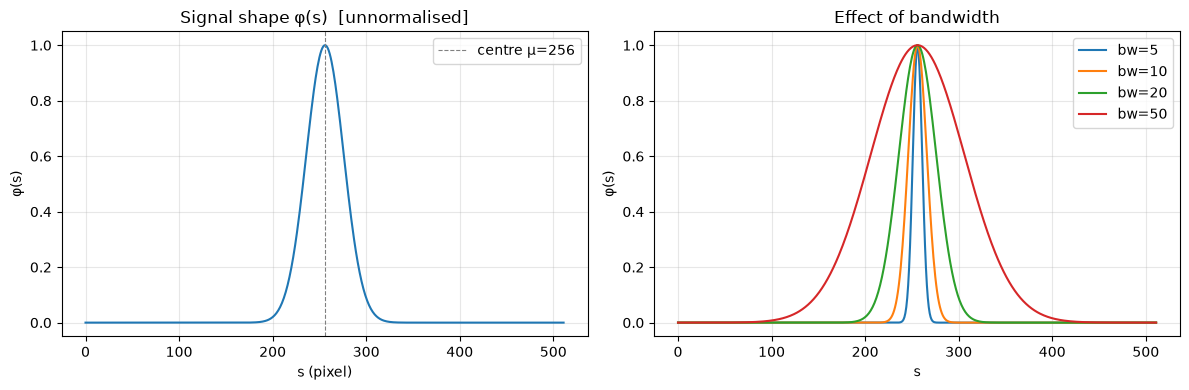

Bump support (±3 sigma):  [196, 316]
Bump peak value: 1.000


In [2]:
def gaussian_unnormalized(s, mu, bw):
    return np.exp(-((s - mu) ** 2) / (2 * bw ** 2))

def gaussian_normalized(s, mu, bw):
    return (1 / (bw * np.sqrt(2 * np.pi))) * np.exp(-((s - mu) ** 2) / (2 * bw ** 2))

phi = gaussian_unnormalized(s, mu, bw_signal)   # the one we will use

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s, phi)
axes[0].set(title="Signal shape φ(s)  [unnormalised]",
            xlabel="s (pixel)", ylabel="φ(s)")
axes[0].axvline(mu, color="gray", ls="--", lw=0.8, label=f"centre μ={mu}")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for bw in [5, 10, 20, 50]:
    axes[1].plot(s, gaussian_unnormalized(s, mu, bw), label=f"bw={bw}")
axes[1].set(title="Effect of bandwidth", xlabel="s", ylabel="φ(s)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Bump support (±3 sigma):  [{mu - 3*bw_signal}, {mu + 3*bw_signal}]")
print(f"Bump peak value: {phi.max():.3f}")


## 2 · Noise generation pipeline

$$w_i(s) \sim \mathcal{N}(0,1) \xrightarrow{\text{convolve with }g} \tilde{e}_i(s) \xrightarrow{\div\,\text{SD}} e_i(s),\quad \text{SD}(e_i)=1$$


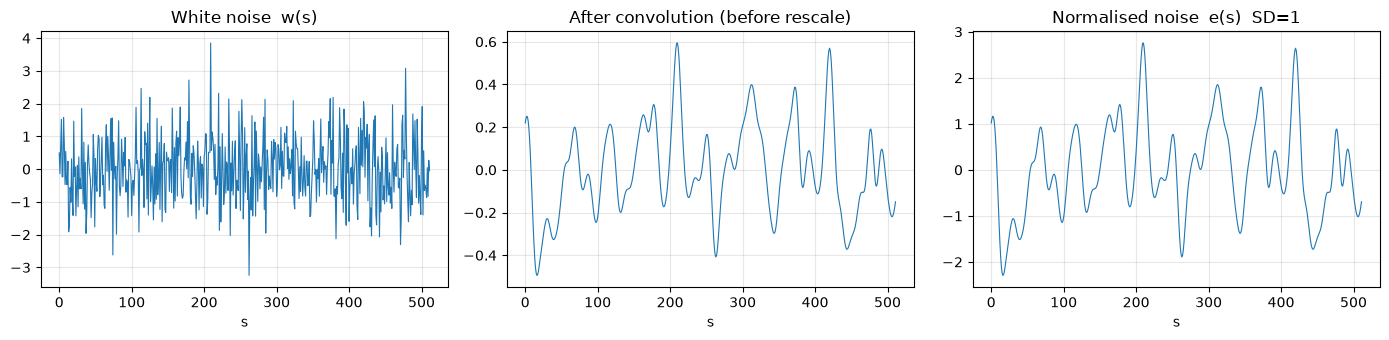

Noise SD after normalisation: 1.000000


In [3]:
def make_gaussian_kernel(sd, truncate=4):
    radius = int(truncate * sd)
    u = np.arange(-radius, radius + 1)
    kernel = np.exp(-(u ** 2) / (2 * sd ** 2))
    return u, kernel / kernel.sum()

_, kernel = make_gaussian_kernel(noise_kernel_sd)

# show one noise instance
w_ex = np.random.normal(0, 1, n_pixels)
e_raw = np.convolve(w_ex, kernel, mode="same")
e_ex  = e_raw / e_raw.std()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(s, w_ex, lw=0.8); axes[0].set(title="White noise  w(s)", xlabel="s"); axes[0].grid(True, alpha=0.3)
axes[1].plot(s, e_raw, lw=0.8); axes[1].set(title="After convolution (before rescale)", xlabel="s"); axes[1].grid(True, alpha=0.3)
axes[2].plot(s, e_ex, lw=0.8); axes[2].set(title="Normalised noise  e(s)  SD=1", xlabel="s"); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Noise SD after normalisation: {e_ex.std():.6f}")


## 3 · Generate the full dataset

For each subject $i$:

$$A_i\sim\mathcal{N}(0,\sigma_A^2), \qquad Y_i(s)=A_i\,\phi(s)+e_i(s)$$

Outputs: **Y** (1000 × 512) and **A** (1000,).


In [4]:
def generate_dataset(n_instances, n_pixels, mu, bw_signal, noise_kernel_sd, sigma_A):
    s = np.arange(n_pixels)
    phi = gaussian_unnormalized(s, mu, bw_signal)
    _, kernel = make_gaussian_kernel(noise_kernel_sd)

    A = np.random.normal(0, sigma_A, size=n_instances)
    Y = np.zeros((n_instances, n_pixels))
    noise_mat = np.zeros((n_instances, n_pixels))

    for i in range(n_instances):
        w = np.random.normal(0, 1, n_pixels)
        e = np.convolve(w, kernel, mode="same")
        e = e / e.std()
        noise_mat[i] = e
        Y[i] = A[i] * phi + e

    return A, Y, noise_mat, phi

A, Y, noise_mat, phi_true = generate_dataset(
    n_instances, n_pixels, mu, bw_signal, noise_kernel_sd, sigma_A)

print(f"Y shape : {Y.shape}   (subjects x pixels)")
print(f"A shape : {A.shape}")
print(f"A mean  : {A.mean():.4f}   A SD: {A.std():.4f}")
print(f"E[Y] across subjects at bump centre: {Y[:, mu].mean():.4f}  (expect ≈0)")

Y shape : (1000, 512)   (subjects x pixels)
A shape : (1000,)
A mean  : 0.1440   A SD: 1.9852
E[Y] across subjects at bump centre: 0.1602  (expect ≈0)


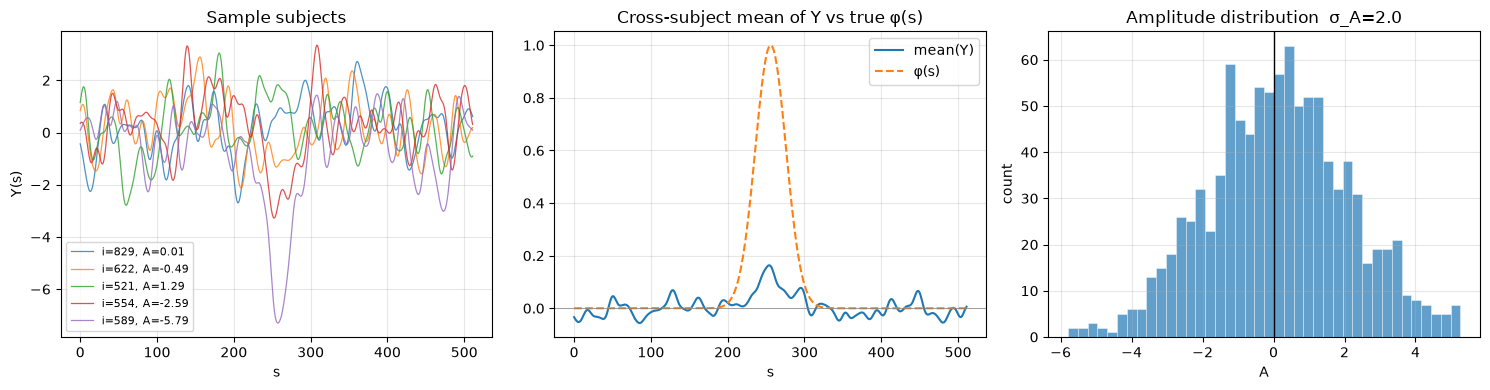

In [5]:
# Sanity-check plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) several individual traces coloured by |A|
sort_idx = np.argsort(np.abs(A))
for rank, i in enumerate(sort_idx[[0, 200, 500, 800, 999]]):
    axes[0].plot(s, Y[i], alpha=0.8, lw=0.9, label=f"i={i}, A={A[i]:.2f}")
axes[0].set(title="Sample subjects", xlabel="s", ylabel="Y(s)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# 2) mean of Y across subjects  (should ≈ 0 everywhere since E[A]=0)
axes[1].plot(s, Y.mean(axis=0), label="mean(Y)")
axes[1].plot(s, phi_true, ls="--", label="φ(s)", lw=1.5)
axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set(title="Cross-subject mean of Y vs true φ(s)", xlabel="s")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3) amplitude histogram
axes[2].hist(A, bins=40, alpha=0.7, edgecolor="white", lw=0.4)
axes[2].axvline(0, color="black", lw=1)
axes[2].set(title=f"Amplitude distribution  σ_A={sigma_A}", xlabel="A", ylabel="count")
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 4 · Direct OLS regression — pixel-wise

With the generative model $Y_i(s) = A_i\,\phi(s)+e_i(s)$, the OLS setup $:$

At each pixel $s\in 1,...,512$, the model is
$$
Y(s) = X\begin{bmatrix}\beta(s)\\\alpha(s)\end{bmatrix}+\varepsilon(s),\quad X = \begin{bmatrix}A_1 & 1 \\ A_2 & 1 \\\vdots & \vdots \\ A_n & 1\end{bmatrix}
$$

The OLS estimator at pixel $s$ is 
$$
\begin{bmatrix}
\hat{\beta}(s)\\\hat{\alpha}(s)
\end{bmatrix} = (X^\top X)^{-1}X^\top Y(s)
$$

In [6]:
n, p = Y.shape
X = np.column_stack([A, np.ones(n)]) # Design matrix X = [A | 1]

XtX = X.T @ X  # (2, 2)
XtY = X.T @ Y  # (2, p)
coeffs = np.linalg.solve(XtX, XtY)  # (2, p)
beta_hat, alpha_hat = coeffs[0], coeffs[1]

Y_hat   = X @ coeffs  #(n, p) — fitted values
resid   = Y - Y_hat  #(n, p) — residuals
df      = n - 2
sigma2  = (resid**2).sum(axis=0) / df  #(p,) — residual variance per pixel

# Var(beta_hat) = sigma2 * [(X'X)^{-1}]_{00}
XtX_inv   = np.linalg.inv(XtX)  # (2, 2)
var_beta  = sigma2 * XtX_inv[0, 0]  # shape (p,)
se_beta   = np.sqrt(var_beta)  # shape (p,)

print(f"beta_hat range: [{beta_hat.min():.4f}, {beta_hat.max():.4f}]")
print(f"alpha_hat range: [{alpha_hat.min():.4f}, {alpha_hat.max():.4f}]")
print(f"Residual mean: {resid.mean():.2e}")

# Quantitative accuracy: MSE
MSE_full = np.mean((beta_hat - phi_true) ** 2)

print("\nOLS estimation accuracy:")
print(f"MSE (all pixels): {MSE_full:.6f}")
print(f"Correlation β̂ vs φ: {np.corrcoef(beta_hat, phi_true)[0,1]:.6f}")

beta_hat range: [-0.0333, 0.9994]
alpha_hat range: [-0.0556, 0.0701]
Residual mean: -1.02e-17

OLS estimation accuracy:
MSE (all pixels): 0.000212
Correlation β̂ vs φ: 0.998605


At each pixel $s$, the test is
$$H_0:\beta(s)=0\quad \text{vs.}\quad H_1:\beta(s)\neq 0$$

Test statistic: $t(s) = \hat{\beta}(s)/\text{SE}(\hat{\beta}(s))$

In [7]:
# t-statistics and two-sided p-values
t_stat = beta_hat / se_beta  # (p,)
p_vals = 2 * stats.t.sf(np.abs(t_stat), df=df)  # (p,)

# Multiple testing correction
alpha = 0.05

# Bonferroni results & threshold
reject_bonf = p_vals < (alpha / n_pixels)
bonf_t_threshold = stats.t.ppf(1 - alpha / (2 * n_pixels), df=df)  # Bonferroni threshold

# Benjamini–Hochberg FDR results & threshold
reject_bh, _, _, _ = multipletests(p_vals, alpha=alpha, method="fdr_bh")
ranks = stats.rankdata(p_vals)
bh_p_threshold = (ranks / n_pixels) * alpha
bh_t_threshold = stats.t.ppf(1 - bh_p_threshold / 2, df=df) 

In [8]:
print(f"Significant pixels (Bonferroni, α={alpha}): {reject_bonf.sum()}/{n_pixels}")
print(f"Significant pixels (BH-FDR, α={alpha}): {reject_bh.sum()}/{n_pixels}")
print(f"True bump support (±3σ, width≈{6*bw_signal}): pixels {mu-3*bw_signal}-{mu+3*bw_signal}")

Significant pixels (Bonferroni, α=0.05): 93/512
Significant pixels (BH-FDR, α=0.05): 105/512
True bump support (±3σ, width≈120): pixels 196-316


The signal shape is a Gaussian bump, which is strictly positive for every pixel $s$ and never reaches exactly zero. To classify pixels into "signal" vs. "null" for computing true/false positive rates, we therefore define the bump support as the region within **3 bandwidths** of the centre:

$$\text{bump\_lo} = \mu - 3\,bw, \qquad \text{bump\_hi} = \mu + 3\,bw$$

At this boundary, the signal has decayed to:

$$\phi(\mu \pm 3bw) = \exp(-4.5) \approx 0.0111$$

i.e. about **1.1% of the peak height**. Pixels inside $[\text{bump\_lo}, \text{bump\_hi}]$ are treated as "true signal" pixels; pixels outside are treated as "true null" pixels for the purposes of computing TPR and FPR.

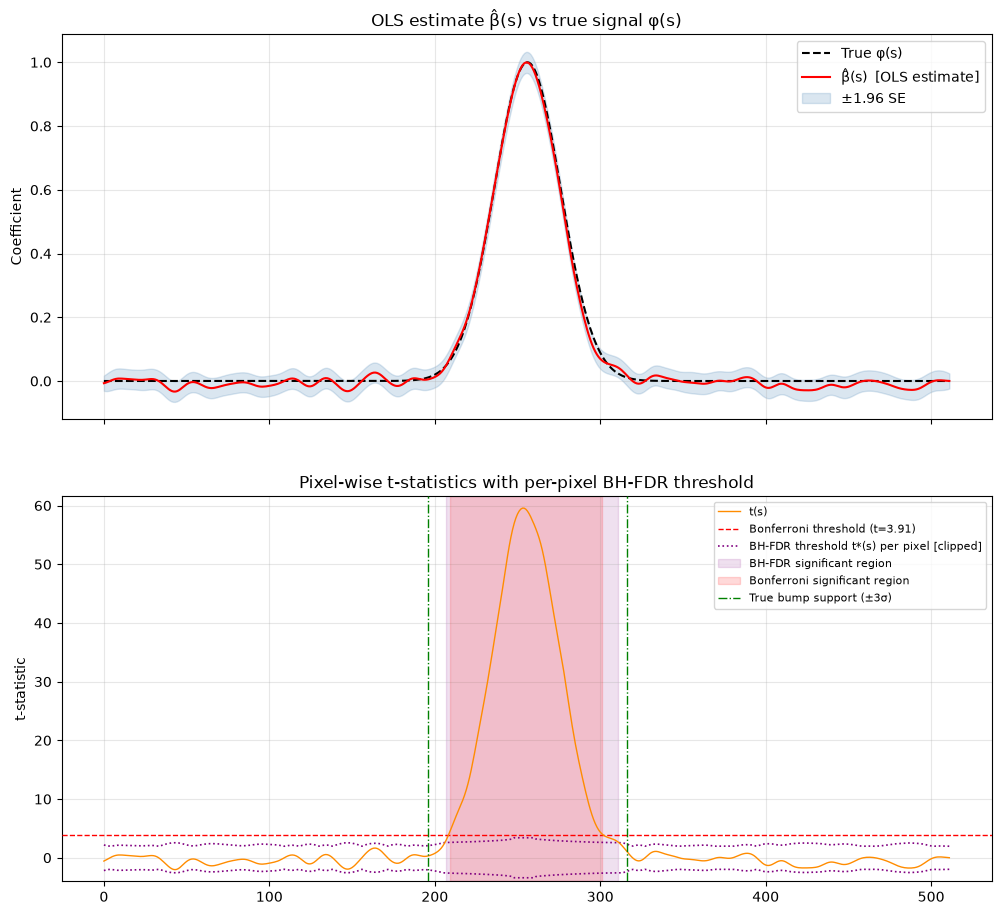

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 11), sharex=True)

# Panel 1 — estimated vs true shape
axes[0].plot(s, phi_true, color="black", lw=1.5, ls="--", label="True φ(s)")
axes[0].plot(s, beta_hat, color="red",   lw=1.5,          label="β̂(s)  [OLS estimate]")
axes[0].fill_between(s, beta_hat - 1.96*se_beta, beta_hat + 1.96*se_beta,
                     alpha=0.2, color="steelblue", label="±1.96 SE")
axes[0].set(ylabel="Coefficient", title="OLS estimate β̂(s) vs true signal φ(s)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2 — t-statistics with correct significance shading
axes[1].plot(s, t_stat, color="darkorange", lw=1, label="t(s)", zorder=4)
axes[1].axhline(bonf_t_threshold, color="red", lw=1, ls="--", label=f"Bonferroni threshold (t={bonf_t_threshold:.2f})", zorder=3)
axes[1].plot(s, bh_t_threshold, color="purple", lw=1.2, ls=":", label="BH-FDR threshold t*(s) per pixel [clipped]", zorder=3)
axes[1].plot(s, -bh_t_threshold, color="purple", lw=1.2, ls=":", zorder=3)

ylo = min(t_stat.min(), 0) - 2
yhi = t_stat.max() + 2
axes[1].set_ylim(ylo, yhi)
axes[1].fill_between(s, ylo, yhi, where=reject_bh, alpha=0.12, color="purple",
                     label="BH-FDR significant region", zorder=1)
axes[1].fill_between(s, ylo, yhi, where=reject_bonf, alpha=0.15, color="red",
                     label="Bonferroni significant region", zorder=2)

# True bump boundary locations
bump_lo = mu - 3 * bw_signal
bump_hi = mu + 3 * bw_signal
axes[1].axvline(bump_lo, color="green", lw=1, ls="-.", label="True bump support (±3σ)", zorder=5)
axes[1].axvline(bump_hi, color="green", lw=1, ls="-.", zorder=5)

axes[1].set(ylabel="t-statistic",
            title="Pixel-wise t-statistics with per-pixel BH-FDR threshold")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.show()

## 5 · OLS sensitivity analysis

Three parameters to change:
1. **Signal amplitude $\sigma_A$** — controls SNR
2. **Bump width $bw\_signal$** — controls spatial extent of the effect
3. **Noise smoothness $noise\_kernel\_sd$** — controls how similar noise looks to signal

We vary one parameter at a time and track:
- **MSE** — mean squared error between $\hat\beta(s)$ and $\phi(s)$
- **True positive rate (TPR)** — fraction of bump pixels declared significant (power)
- **False positive rate (FPR)** — fraction of flat pixels declared significant (type-I error)

---
#### True Positive Rate and False Positive Rate
Let `bump_mask(s)` be the indicator of whether pixel $s$ belongs to the true signal region (within the bump support)

$$
\text{bump\_mask}(s) = \mathbb{1}\left[\,|s - \mu| \leq 3 \cdot bw\_signal\,\right]
$$

##### True Positive Rate (TPR / Power / Sensitivity)

The proportion of truly signal-bearing pixels that were correctly declared significant:

$$
\text{TPR} = \frac{\#\{s : \text{reject}(s) = 1 \ \text{and} \ \text{bump\_mask}(s) = 1\}}{\#\{s : \text{bump\_mask}(s) = 1\}}
= \frac{1}{|S_{\text{signal}}|}\sum_{s \,\in\, S_{\text{signal}}} \text{reject}(s)
$$

where $S_{\text{signal}} = \{s : \text{bump\_mask}(s) = 1\}$ is the set of true-signal pixels.


##### False Positive Rate (FPR / Type-I Error Rate)

The proportion of truly null pixels (outside the bump) that were incorrectly declared
significant:

$$
\text{FPR} = \frac{\#\{s : \text{reject}(s) = 1 \ \text{and} \ \text{bump\_mask}(s) = 0\}}{\#\{s : \text{bump\_mask}(s) = 0\}}
= \frac{1}{|S_{\text{null}}|}\sum_{s \,\in\, S_{\text{null}}} \text{reject}(s)
$$

where $S_{\text{null}} = \{s : \text{bump\_mask}(s) = 0\}$ is the set of true-null pixels.

In [10]:
def run_ols(Y, A, phi_true, mu, bw_signal, alpha=0.05):
    """
    Pixel-wise OLS with intercept using design matrix X = [A | 1].
    Returns: beta_hat, t_stat, reject (BH-FDR), MSE, TPR, FPR
    """
    n, p   = Y.shape
    X      = np.column_stack([A, np.ones(n)])   # (n, 2)
    XtX    = X.T @ X                            # (2, 2)
    XtY    = X.T @ Y                            # (2, p)
    coeffs = np.linalg.solve(XtX, XtY)         # (2, p)

    beta_hat  = coeffs[0]                       # slope  — estimated φ(s)
    Y_hat     = X @ coeffs                      # fitted values
    resid     = Y - Y_hat                       # residuals
    sigma2    = (resid**2).sum(axis=0) / (n-2)  # residual variance

    XtX_inv  = np.linalg.inv(XtX)
    se       = np.sqrt(sigma2 * XtX_inv[0, 0])  # SE of slope

    t_stat   = beta_hat / se
    p_vals   = 2 * stats.t.sf(np.abs(t_stat), df=n-2)
    reject, _, _, _ = multipletests(p_vals, alpha=alpha, method="fdr_bh")

    bump_mask = np.abs(np.arange(p) - mu) <= 3 * bw_signal
    MSE = np.mean((beta_hat - phi_true)**2)
    TPR  = reject[bump_mask].mean()
    FPR  = reject[~bump_mask].mean()
    return beta_hat, t_stat, reject, MSE, TPR, FPR

In [11]:
def generate_dataset_seeded(n_instances, n_pixels, mu, bw_signal, noise_kernel_sd, sigma_A, seed):
    np.random.seed(seed)
    return generate_dataset(n_instances, n_pixels, mu, bw_signal, noise_kernel_sd, sigma_A)

SEED = 42

# Sweep 1: sigma_A (signal amplitude / SNR)
sigma_A_vals = [0.25, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0]
results_snr = []
for sa in sigma_A_vals:
    Ai, Yi, _, phi_i = generate_dataset_seeded(n_instances, n_pixels, mu, bw_signal, noise_kernel_sd, sa, seed=SEED)
    _, _, _, mse, tpr, fpr = run_ols(Yi, Ai, phi_i, mu, bw_signal)
    results_snr.append((sa, mse, tpr, fpr))

# Sweep 2: bw_signal (bump width)
bw_signal_vals = [5, 10, 20, 30, 40, 50]
results_bw = []
for bw in bw_signal_vals:
    Ai, Yi, _, phi_i = generate_dataset_seeded(n_instances, n_pixels, mu, bw, noise_kernel_sd, sigma_A, seed=SEED)
    _, _, _, mse, tpr, fpr = run_ols(Yi, Ai, phi_i, mu, bw)
    results_bw.append((bw, mse, tpr, fpr))

# Sweep 3: noise_kernel_sd (noise smoothness)
nk_vals = list(range(1, 16, 1))
results_nk = []
for nk in nk_vals:
    Ai, Yi, _, phi_i = generate_dataset_seeded(n_instances, n_pixels, mu, bw_signal, nk, sigma_A, seed=SEED)
    _, _, _, mse, tpr, fpr = run_ols(Yi, Ai, phi_i, mu, bw_signal)
    results_nk.append((nk, mse, tpr, fpr))

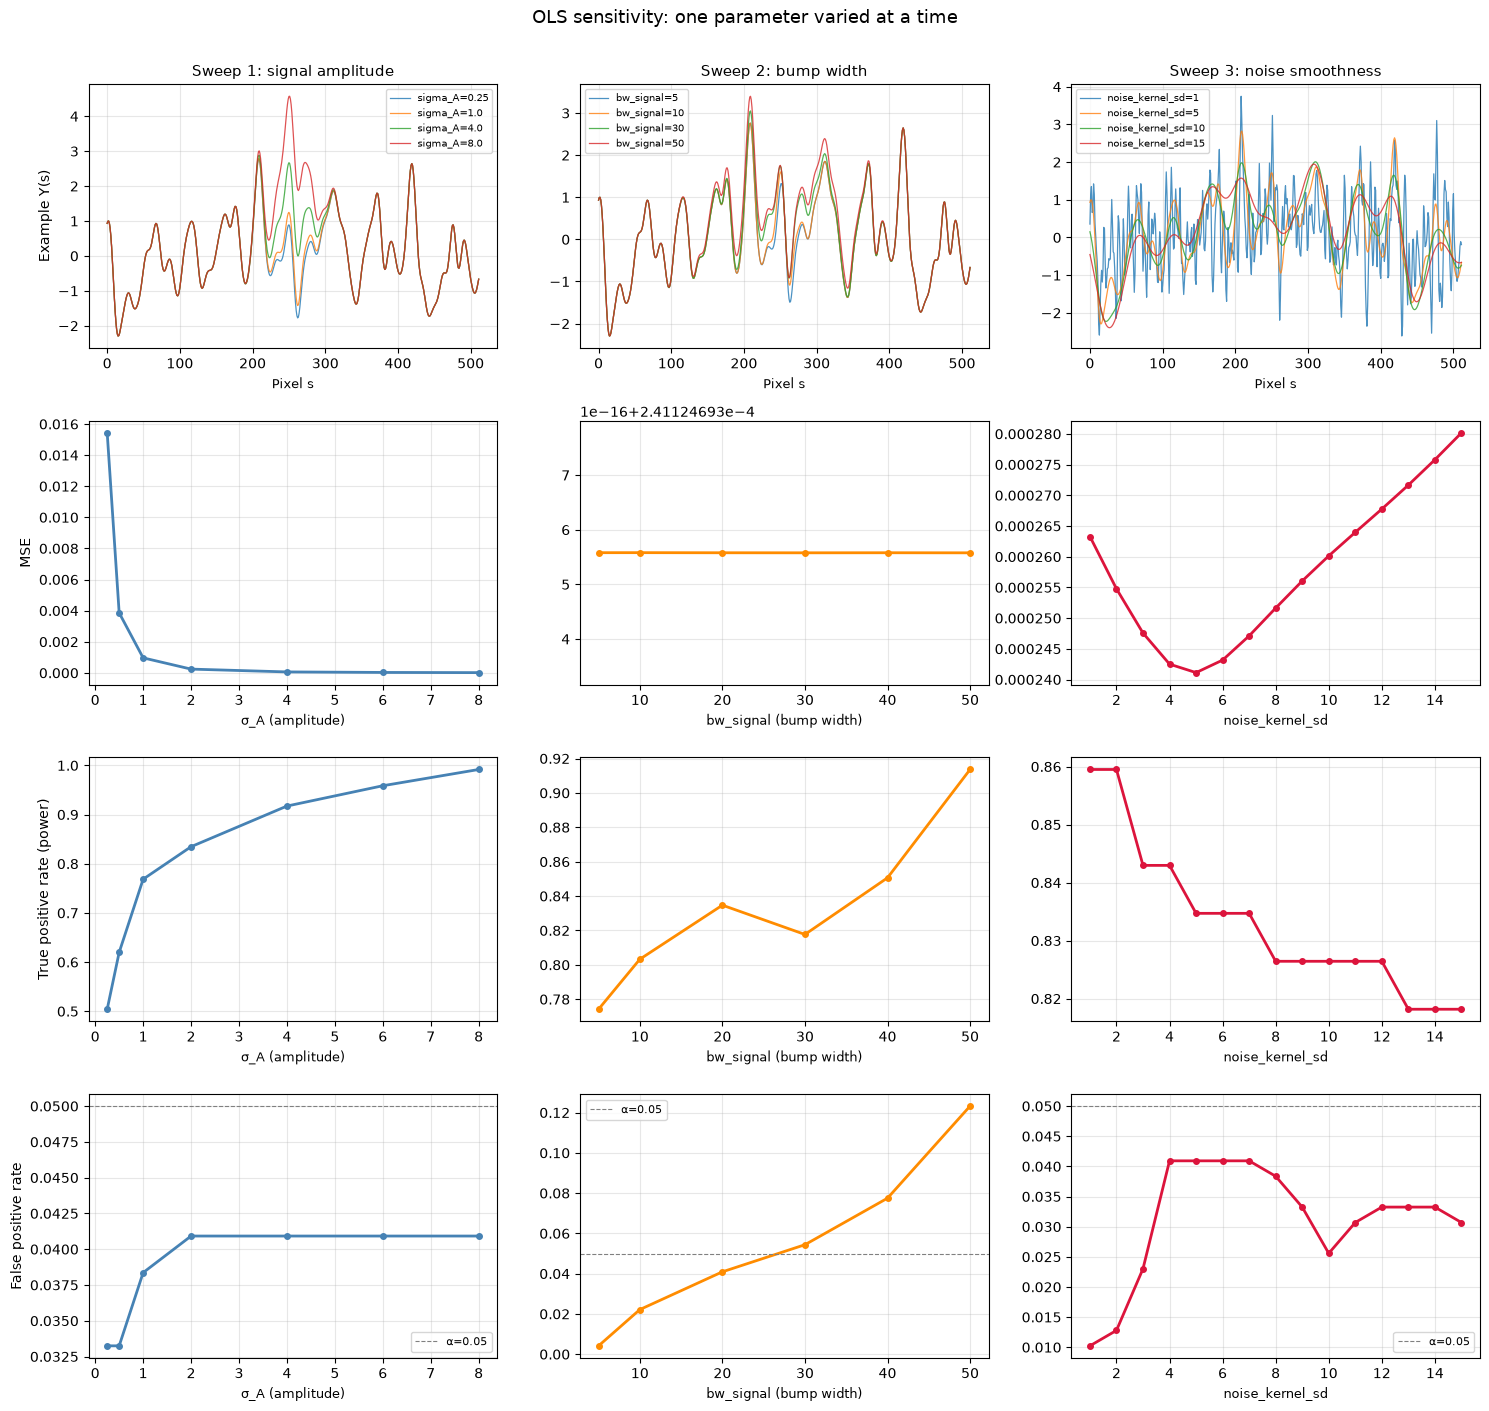

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))

sweeps = [
    (results_snr, sigma_A_vals,   "σ_A (amplitude)",        "Sweep 1: signal amplitude",
     dict(bw_signal=bw_signal, noise_kernel_sd=noise_kernel_sd)),
    (results_bw,  bw_signal_vals, "bw_signal (bump width)", "Sweep 2: bump width",
     dict(sigma_A=sigma_A, noise_kernel_sd=noise_kernel_sd)),
    (results_nk,  nk_vals,        "noise_kernel_sd",        "Sweep 3: noise smoothness",
     dict(sigma_A=sigma_A, bw_signal=bw_signal)),
]
metrics = ["MSE", "True positive rate (power)", "False positive rate"]
colours = ["steelblue", "darkorange", "crimson"]

def example_Y_trace(sigma_A, bw_signal, noise_kernel_sd, seed=42):
    """Generate one example subject's Y(s) trace for visual reference."""
    np.random.seed(seed)
    phi = gaussian_unnormalized(s, mu, bw_signal)
    A = np.random.normal(0, sigma_A, size=1)[0]
    _, k = make_gaussian_kernel(noise_kernel_sd)
    w = np.random.normal(0, 1, n_pixels)
    e = np.convolve(w, k, mode="same")
    e = e / e.std()
    return A * phi + e

for col, (res, xvals, xlabel, title, fixed) in enumerate(sweeps):
    vals = np.array(res)

    # Row 0 (now first): example observed Y(s) traces at representative parameter values
    ax = axes[0][col]
    sample_idx = np.linspace(0, len(xvals) - 1, 4).astype(int)
    param_key = ["sigma_A", "bw_signal", "noise_kernel_sd"][col]
    for idx in sample_idx:
        val = xvals[idx]
        params = dict(fixed)
        params[param_key] = val
        y_trace = example_Y_trace(params["sigma_A"], params["bw_signal"], params["noise_kernel_sd"])
        ax.plot(s, y_trace, lw=0.9, alpha=0.8, label=f"{param_key}={val}")
    ax.set_title(title, fontsize=11)
    if col == 0:
        ax.set_ylabel("Example Y(s)", fontsize=10)
    ax.set_xlabel("Pixel s", fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Rows 1-3 (shifted down by one): MSE, TPR, FPR vs parameter
    for row, (metric, col_idx) in enumerate(zip(metrics, [1, 2, 3]), start=1):
        ax = axes[row][col]
        ax.plot(xvals, vals[:, col_idx], "o-", color=colours[col], lw=2, ms=4)
        if col == 0:
            ax.set_ylabel(metric, fontsize=10)
        ax.set_xlabel(xlabel, fontsize=9)
        if row == 3:    # FPR reference line — now the last row
            ax.axhline(0.05, color="gray", ls="--", lw=0.8, label="α=0.05")
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("OLS sensitivity: one parameter varied at a time", fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

In [13]:
np.sqrt(0.84 * 0.16 / 1000)

np.float64(0.01159310139695155)

## 6 · Multiscale analysis — pre-smooth Y, then regress

Pre-convolve each subject's observed signal $Y_i(s)$ with a Gaussian kernel of bandwidth $h$:

$$Y_i^{(h)}(s) = \sum_u g_h(u)\cdot Y_i(s-u),\quad g_h(u) = \frac{1}{\sqrt{2\pi}h}\exp\big(-\frac{u^2}{2h^2}\big)$$

then run the same pixel-wise OLS on $Y^{(h)}$:
- $h \approx bw\_signal$: the kernel acts as a **matched filter** — it resonates with the bump shape and suppresses noise that varies faster than the bump. SNR improves.  
- $h \ll bw\_signal$: little change — the signal is already smooth relative to $h$.  
- $h \gg bw\_signal$: the bump gets blurred out and lose spatial precision, hurting both estimation accuracy and localization.

#### Re-normalise after smoothing
When convolve $e(s)$ with a kernel $g_h$:
$$
e^{(h)}(s) = (e * g_h)(s) = \sum_u g_h(u)\cdot e(s-u)
$$
Since each $e(s-u)$ is approximately independent with variance 1, the variance of the weighted sum is:
$$\text{Var}(e^{(h)}(s))= \sum_u g_h(u)^2\cdot\text{Var}(e(s-u))=\sum_u g_h(u)^2\cdot 1 = ||g_h||^2_2 < 1$$

We normalise by the theoretical noise SD after convolution: $\text{SD}(e^{(h)}) = \|g_h\|_2$ (since $e$ started at SD=1).


In [14]:
from scipy.ndimage import gaussian_filter1d

def multiscale_smooth(Y, h):
    """
    Pre-smooth every subject's Y(s) with a Gaussian kernel of SD=h.
    """
    Y_smooth = np.array([gaussian_filter1d(Y[i], sigma=h) for i in range(Y.shape[0])])

    # After Gaussian smoothing with SD=h, noise variance scales by:
    #   integral of g^2 = 1 / (2 * sqrt(pi) * h)
    # Dividing by this restores noise SD to 1.
    noise_sd_after = 1.0 / np.sqrt(2 * np.sqrt(np.pi) * h)
    Y_smooth /= noise_sd_after
    return Y_smooth

h_vals = [1, 5, 10, 20, 25, 40, 50, 80]
multiscale_results = []
beta_hats_ms = {}

for h in h_vals:
    Y_h = multiscale_smooth(Y, h)
    b_h, t_h, rej_h, mse_h, tpr_h, fpr_h = run_ols(Y_h, A, phi_true, mu, bw_signal)
    multiscale_results.append((h, mse_h, tpr_h, fpr_h))
    beta_hats_ms[h] = b_h
# Baseline: no pre-smoothing
_, _, _, mse_raw, tpr_raw, fpr_raw = run_ols(Y, A, phi_true, mu, bw_signal)

Plot 1: estimate β̂(s) for each pre-smoothing bandwidth — to see visually how the estimate sharpens then blurs

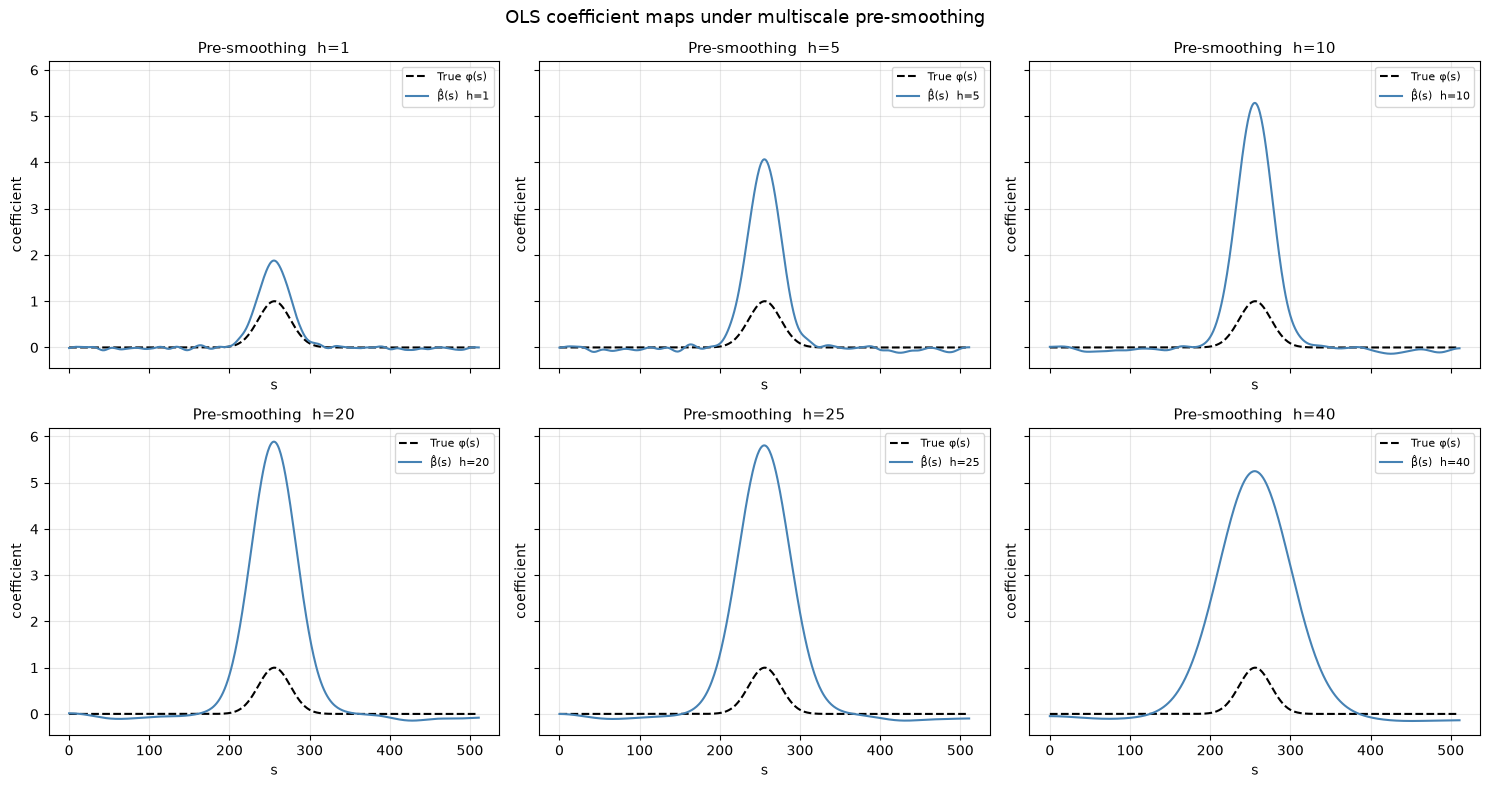

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, h in zip(axes, h_vals):
    ax.plot(s, phi_true, color="black", lw=1.5, ls="--", label="True φ(s)")
    ax.plot(s, beta_hats_ms[h], color="steelblue", lw=1.5, label=f"β̂(s)  h={h}")
    ax.set_title(f"Pre-smoothing  h={h}", fontsize=11)
    ax.set(xlabel="s", ylabel="coefficient")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("OLS coefficient maps under multiscale pre-smoothing", fontsize=13)
plt.tight_layout(); plt.show()


MSE / TPR / FPR vs h — to confirm the optimal scale lands near the true bump width

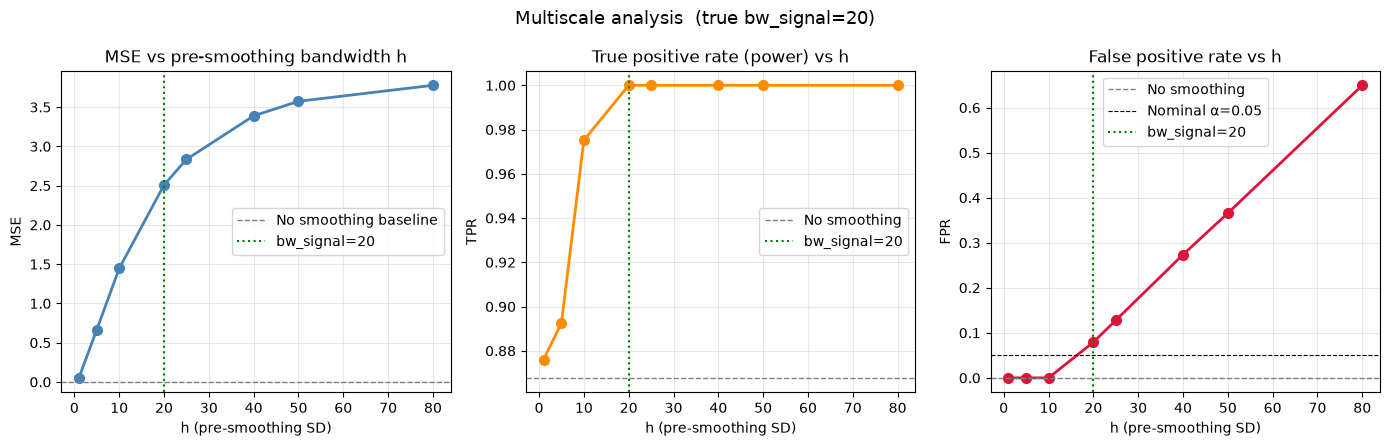

In [16]:
h_arr  = np.array([r[0] for r in multiscale_results])
mse_arr = np.array([r[1] for r in multiscale_results])
tpr_arr  = np.array([r[2] for r in multiscale_results])
fpr_arr  = np.array([r[3] for r in multiscale_results])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].plot(h_arr, mse_arr, "o-", color="steelblue", lw=2, ms=7)
axes[0].axhline(mse_raw, color="gray", ls="--", lw=1, label="No smoothing baseline")
axes[0].axvline(bw_signal, color="green", ls=":", lw=1.5, label=f"bw_signal={bw_signal}")
axes[0].set(title="MSE vs pre-smoothing bandwidth h",
            xlabel="h (pre-smoothing SD)", ylabel="MSE")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(h_arr, tpr_arr, "o-", color="darkorange", lw=2, ms=7)
axes[1].axhline(tpr_raw, color="gray", ls="--", lw=1, label="No smoothing")
axes[1].axvline(bw_signal, color="green", ls=":", lw=1.5, label=f"bw_signal={bw_signal}")
axes[1].set(title="True positive rate (power) vs h",
            xlabel="h (pre-smoothing SD)", ylabel="TPR")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(h_arr, fpr_arr, "o-", color="crimson", lw=2, ms=7)
axes[2].axhline(fpr_raw, color="gray", ls="--", lw=1, label="No smoothing")
axes[2].axhline(0.05, color="black", ls="--", lw=0.8, label="Nominal α=0.05")
axes[2].axvline(bw_signal, color="green", ls=":", lw=1.5, label=f"bw_signal={bw_signal}")
axes[2].set(title="False positive rate vs h",
            xlabel="h (pre-smoothing SD)", ylabel="FPR")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Multiscale analysis  (true bw_signal={bw_signal})", fontsize=13)
plt.tight_layout(); plt.show()


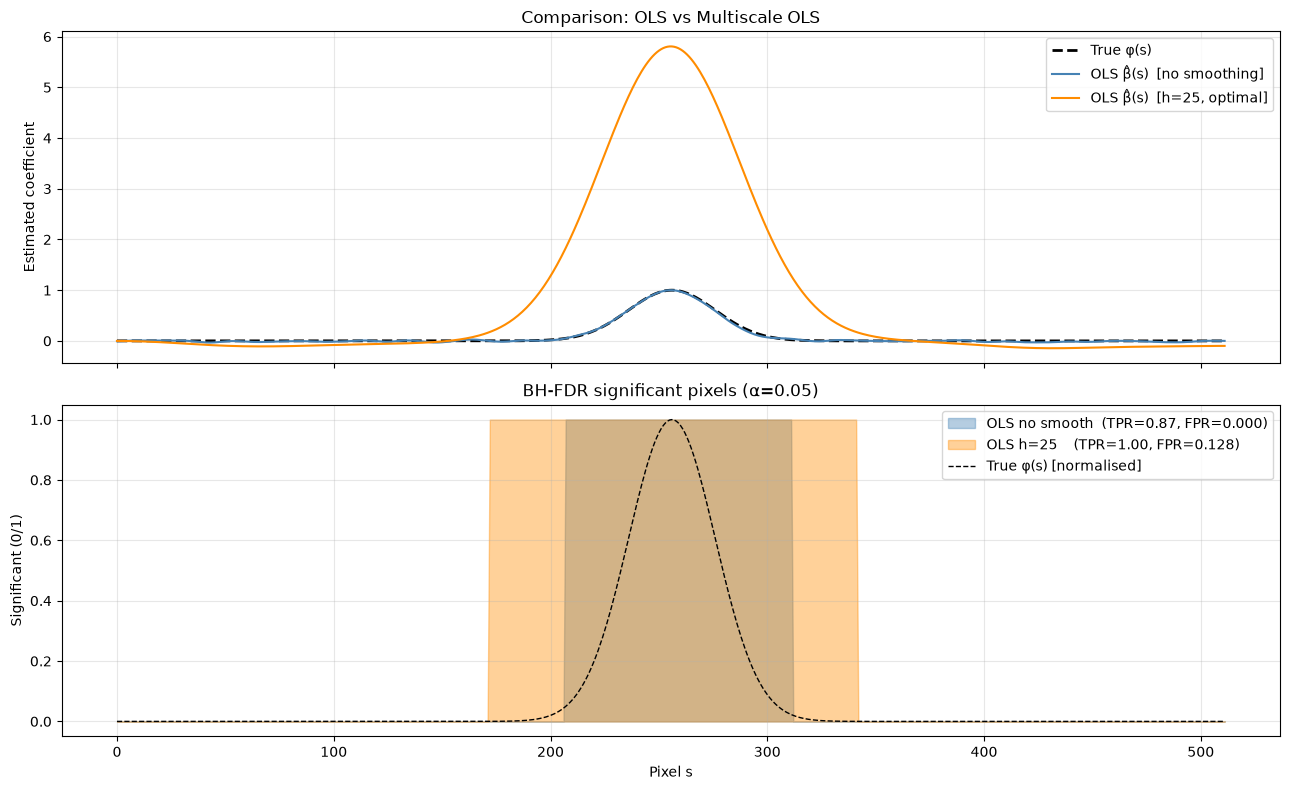

In [17]:
# Manually determine the best h based on MSE (or TPR/FPR tradeoff)
best_h = 25
best_h_idx = np.where(h_arr == best_h)[0][0]

# Final summary figure 
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Panel 1: coefficient maps
axes[0].plot(s, phi_true,              color="black",      lw=2,   ls="--", label="True φ(s)")
axes[0].plot(s, beta_hat,              color="steelblue",  lw=1.5,          label="OLS β̂(s)  [no smoothing]")
axes[0].plot(s, beta_hats_ms[best_h], color="darkorange", lw=1.5,          label=f"OLS β̂(s)  [h={best_h}, optimal]")
axes[0].set(ylabel="Estimated coefficient",
            title="Comparison: OLS vs Multiscale OLS")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Panel 2: significance maps for each method
Y_opt = multiscale_smooth(Y, best_h)
b_opt = (A @ Y_opt) / (A @ A)
resid_opt = Y_opt - np.outer(A, b_opt)
sigma2_opt = (resid_opt**2).sum(axis=0) / (n_instances - 1)
se_opt = np.sqrt(sigma2_opt / (A @ A))
t_opt = b_opt / se_opt
p_opt = 2 * stats.t.sf(np.abs(t_opt), df=n_instances-1)
rej_opt, _, _, _ = multipletests(p_opt, alpha=0.05, method="fdr_bh")

axes[1].fill_between(s, reject_bh.astype(float),  alpha=0.4, color="steelblue",  label=f"OLS no smooth  (TPR={tpr_raw:.2f}, FPR={fpr_raw:.3f})")
axes[1].fill_between(s, rej_opt.astype(float),     alpha=0.4, color="darkorange", label=f"OLS h={best_h}    (TPR={tpr_arr[best_h_idx]:.2f}, FPR={fpr_arr[best_h_idx]:.3f})")
axes[1].plot(s, phi_true / phi_true.max(), color="black", ls="--", lw=1, label="True φ(s) [normalised]")
axes[1].set(xlabel="Pixel s", ylabel="Significant (0/1)",
            title="BH-FDR significant pixels (α=0.05)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 7 · 1D Convolutional Autoencoder on the Simulated Data

This step validates whether the OLS-on-encoder-activations methodology correctly recovers the known signal location. 

Fit on the same `Y` array already generated and validated by the OLS and
multiscale analyses:

$$
Y \in \mathbb{R}^{1000 \times 512}, \qquad Y_i(s) = A_i \cdot \phi(s) + e_i(s)
$$

### Architecture
A small 1D convolutional autoencoder with three encoder layers and a bottleneck latent
space. 

The autoencoder is trained purely for reconstruction; no information about the amplitude A is used during training. Reconstruction loss:

$$
\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n} \big\| Y_i - \hat{Y}_i \big\|_2^2
$$

where $\hat{Y}_i$ is the model's reconstruction of subject $i$'s observation.

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import optuna, warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

torch.manual_seed(42)

class ConvAE1D(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=9, padding=4),   nn.ReLU(),  # 8 channels stride 1
            nn.Conv1d(8, 16, kernel_size=9, padding=4, stride=2), nn.ReLU(),  # 16 channels stride 2
            nn.Conv1d(16, 32, kernel_size=9, padding=4, stride=2), nn.ReLU(), # 32 channels stride 2
        )
        self.flatten = nn.Flatten()
        self.fc_latent = nn.Linear(32 * 128, latent_dim)   # latent code z
        self.fc_decode = nn.Linear(latent_dim, 32 * 128)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=9, padding=4, stride=2, output_padding=1), nn.ReLU(),
            nn.ConvTranspose1d(16, 8, kernel_size=9, padding=4, stride=2, output_padding=1), nn.ReLU(),
            nn.Conv1d(8, 1, kernel_size=9, padding=4),
        )

    def forward(self, x):
        h1 = self.encoder[0:2](x)      # layer 1 activations
        h2 = self.encoder[2:4](h1)     # layer 2 activations
        h3 = self.encoder[4:6](h2)     # layer 3 activations (bottleneck input)
        flat = self.flatten(h3)
        z = self.fc_latent(flat)       # latent code
        recon_flat = self.fc_decode(z)
        recon = recon_flat.view(h3.shape)
        out = self.decoder(recon)
        return out, {'layer1': h1, 'layer2': h2, 'layer3': h3, 'latent': z}

/opt/anaconda3/envs/XAI/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Dataset
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)   # (1000, 1, 512)
A_tensor = torch.tensor(A, dtype=torch.float32)                 # (1000,)
dataset = TensorDataset(Y_tensor, A_tensor)

n_val   = 200
n_train = n_instances - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(42))
print(f"Train: {n_train}  Val: {n_val}")

Train: 800  Val: 200


In [28]:
# Hyperparameter tuning with Optuna
# Searches over learning rate, latent dimension, and batch size.
# Only reconstruction loss is used — A is not seen during training.

def train_eval(lr, latent_dim, batch_size, n_epochs=30):
    model  = ConvAE1D(latent_dim=latent_dim)
    optim  = torch.optim.Adam(model.parameters(), lr=lr)
    crit   = nn.MSELoss()
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=n_val)

    for _ in range(n_epochs):
        model.train()
        for Yb, _ in loader:
            optim.zero_grad()
            recon, _ = model(Yb)
            crit(recon, Yb).backward()
            optim.step()

    model.eval()
    with torch.no_grad():
        Yv, _ = next(iter(val_loader))
        recon_v, _ = model(Yv)
        val_loss = crit(recon_v, Yv).item()
    return model, val_loss

def objective(trial):
    lr         = trial.suggest_float("lr",         1e-4, 1e-2, log=True)
    latent_dim = trial.suggest_categorical("latent_dim", [8, 16, 32])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    _, val_loss = train_eval(lr, latent_dim, batch_size)
    return val_loss

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15, show_progress_bar=False)

best = study.best_params
print(f"Best hyperparameters: {best}")
print(f"Best validation loss: {study.best_value:.6f}")

Best hyperparameters: {'lr': 0.00026705116903587013, 'latent_dim': 32, 'batch_size': 64}
Best validation loss: 0.198790


In [29]:
#Final training with best hyperparameters (more epochs) 
best_lr = best['lr']
best_ld = best['latent_dim']
best_bs = best['batch_size']

model_final, _ = train_eval(best_lr, best_ld, best_bs, n_epochs=200)

# evaluate final reconstruction loss on validation set
crit = nn.MSELoss()
model_final.eval()
val_loader = DataLoader(val_ds, batch_size=n_val)
with torch.no_grad():
    Yv, _ = next(iter(val_loader))
    recon_v, _ = model_final(Yv)
    final_val_loss = crit(recon_v, Yv).item()

print(f"Final val reconstruction loss: {final_val_loss:.6f}")
print(f"Latent dim: {best_ld}")

Final val reconstruction loss: 0.307224
Latent dim: 32


In [30]:
# Extract latent activations for all subjects 
model_final.eval()
with torch.no_grad():
    _, activations = model_final(Y_tensor)

latent_acts = activations['latent'].numpy()   # (n_instances, latent_dim)
print(f"Latent activations shape: {latent_acts.shape}")

Latent activations shape: (1000, 32)


In [34]:
# Univariate OLS: predict A from each latent dimension independently
# For each dimension d: A = alpha_d + beta_d * z_d + epsilon

n_latent     = latent_acts.shape[1]
beta_uni     = np.zeros(n_latent)    # slopes
alpha_uni    = np.zeros(n_latent)    # intercepts
t_uni        = np.zeros(n_latent)    # t-statistics
A_hat_uni    = np.zeros((len(A), n_latent))   # predicted A per dimension

for d in range(n_latent):
    X      = np.column_stack([latent_acts[:, d], np.ones(len(A))])  # (n, 2)
    coeffs = np.linalg.solve(X.T @ X, X.T @ A)       # outcome is A
    resid  = A - X @ coeffs
    sigma2 = (resid**2).sum() / (len(A) - 2)
    se     = np.sqrt(sigma2 * np.linalg.inv(X.T @ X)[0, 0])

    beta_uni[d]      = coeffs[0]
    alpha_uni[d]     = coeffs[1]
    t_uni[d]         = coeffs[0] / se
    A_hat_uni[:, d]  = X @ coeffs

# multiple testing
p_uni = 2 * stats.t.sf(np.abs(t_uni), df=len(A) - 2)
reject_uni, _, _, _ = multipletests(p_uni, alpha=0.05, method="fdr_bh")

# R² per dimension
SS_tot  = ((A - A.mean())**2).sum()
r2_uni  = np.array([1 - ((A - A_hat_uni[:, d])**2).sum() / SS_tot
                     for d in range(n_latent)])

print(f"Significant latent dims (BH-FDR, univariate): {reject_uni.sum()}/{n_latent}")
print(f"Which dims: {np.where(reject_uni)[0]}")

Significant latent dims (BH-FDR, univariate): 30/32
Which dims: [ 0  1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 30 31]


In [35]:
# Joint OLS: predict A from all latent dimensions simultaneously 
X_joint  = np.column_stack([latent_acts, np.ones(len(A))])   # (n, latent_dim+1)
c_joint  = np.linalg.solve(X_joint.T @ X_joint, X_joint.T @ A)
A_hat_joint  = X_joint @ c_joint
resid_joint  = A - A_hat_joint

df_joint     = len(A) - n_latent - 1
sigma2_joint = (resid_joint**2).sum() / df_joint
R2_joint     = 1 - (resid_joint**2).sum() / SS_tot
R2_adj       = 1 - (1 - R2_joint) * (len(A) - 1) / df_joint

print(f"Joint R²          : {R2_joint:.4f}")
print(f"Adjusted R²       : {R2_adj:.4f}")
print(f"Best univariate R²: {r2_uni.max():.4f}  (dim {r2_uni.argmax()})")
print(f"Lift from joint   : {R2_joint - r2_uni.max():.4f}  "
      f"(how much adding all other dims helps beyond the best single dim)")

Joint R²          : 0.8854
Adjusted R²       : 0.8817
Best univariate R²: 0.4316  (dim 14)
Lift from joint   : 0.4539  (how much adding all other dims helps beyond the best single dim)


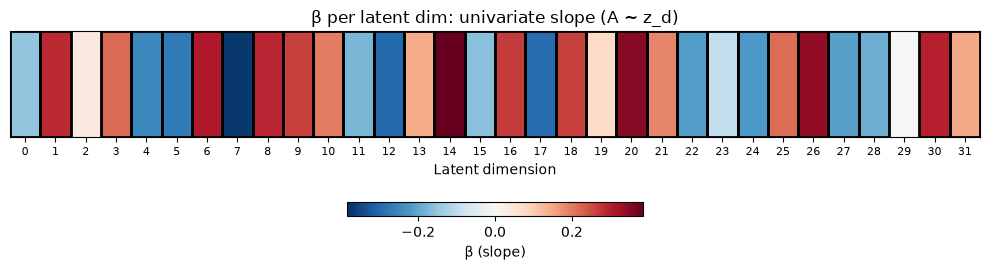

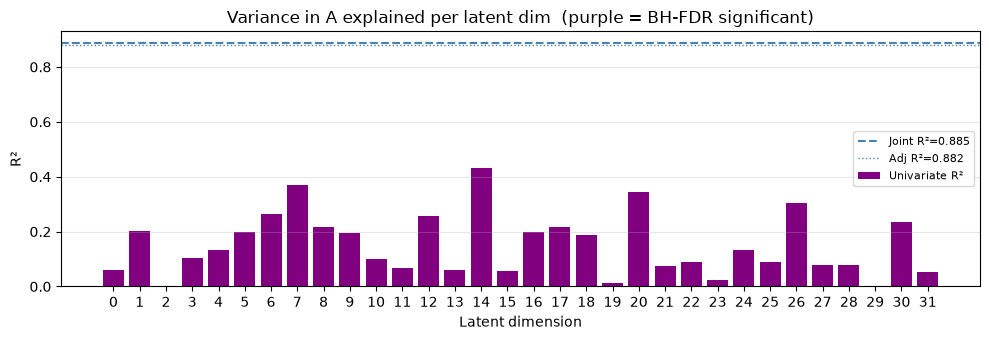

In [36]:
# ── Plot 1: coefficient map — beta per latent dim vs A ────────────────────
fig, ax = plt.subplots(figsize=(10, 2.8))
vmax = np.abs(beta_uni).max()
im   = ax.imshow(beta_uni.reshape(1, -1), cmap="RdBu_r", aspect="auto",
                 vmin=-vmax, vmax=vmax)
ax.set_yticks([])
ax.set_xticks(range(n_latent))
ax.set_xticklabels([str(d) for d in range(n_latent)], fontsize=8)
ax.set_xlabel("Latent dimension")
ax.set_title("β per latent dim: univariate slope (A ~ z_d)")
for d in range(n_latent):
    if reject_uni[d]:
        ax.add_patch(plt.Rectangle((d-0.5, -0.5), 1, 1, fill=False,
                                   edgecolor="black", lw=2))
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.35, fraction=0.08)
cbar.set_label("β (slope)")
plt.tight_layout(); plt.show()

# ── Plot 2: R² per latent dim with joint R² reference ─────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ["purple" if r else "lightgray" for r in reject_uni]
ax.bar(range(n_latent), r2_uni, color=colors, label="Univariate R²")
ax.axhline(R2_joint, color="steelblue", ls="--", lw=1.5,
           label=f"Joint R²={R2_joint:.3f}")
ax.axhline(R2_adj,   color="steelblue", ls=":",  lw=1,
           label=f"Adj R²={R2_adj:.3f}")
ax.set_xlabel("Latent dimension")
ax.set_ylabel("R²")
ax.set_xticks(range(n_latent))
ax.set_title("Variance in A explained per latent dim  (purple = BH-FDR significant)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

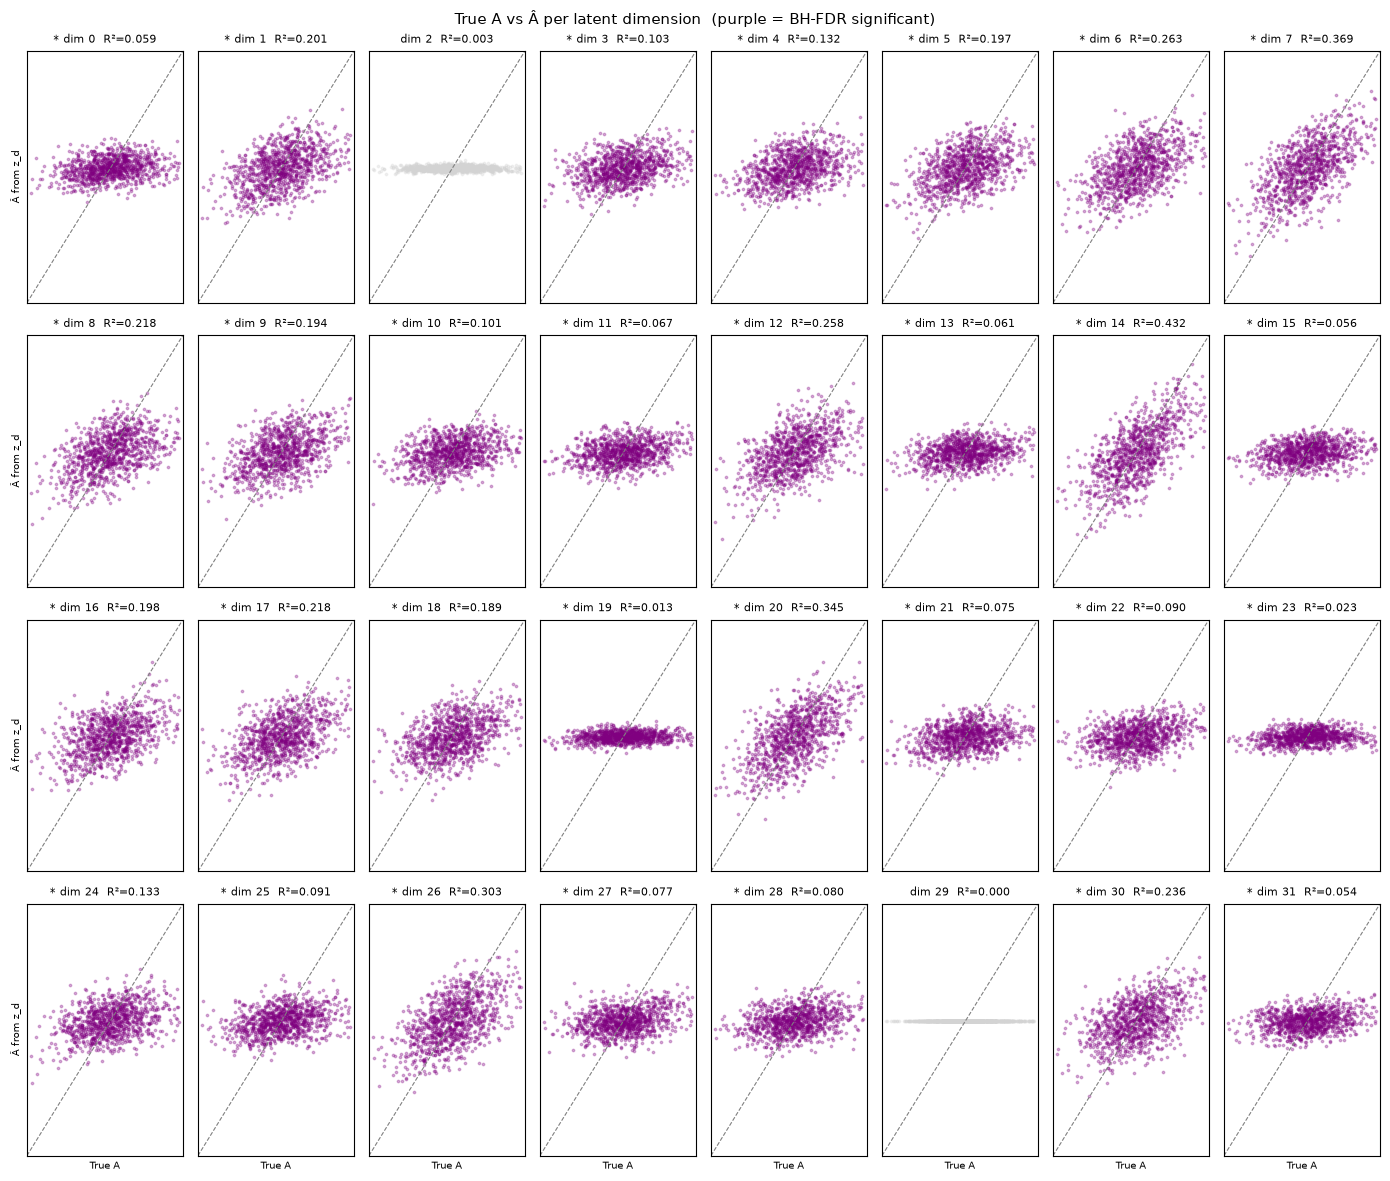

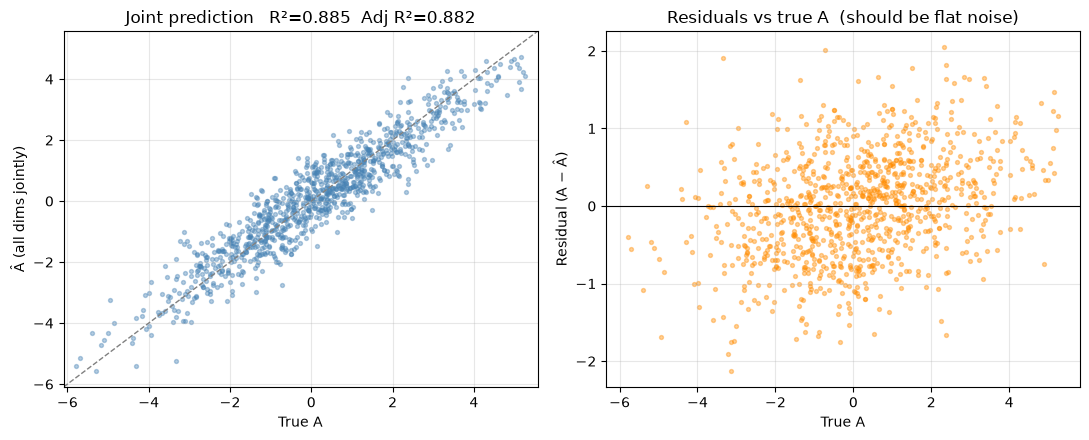

In [37]:
# Plot 3: true A vs A_hat — per dim grid
ncols = 8
nrows = int(np.ceil(n_latent / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3))
axes = axes.flatten()
lims = [A.min()-0.3, A.max()+0.3]

for d in range(n_latent):
    ax = axes[d]
    col = "purple" if reject_uni[d] else "lightgray"
    ax.scatter(A, A_hat_uni[:, d], s=3, alpha=0.3, color=col)
    ax.plot(lims, lims, color="gray", ls="--", lw=0.8)
    sig = "* " if reject_uni[d] else ""
    ax.set_title(f"{sig}dim {d}  R²={r2_uni[d]:.3f}", fontsize=8)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xticks([]); ax.set_yticks([])
    if d % ncols == 0:
        ax.set_ylabel("Â from z_d", fontsize=7)
    if d >= (nrows-1)*ncols:
        ax.set_xlabel("True A", fontsize=7)

for ax in axes[n_latent:]:
    ax.set_visible(False)

plt.suptitle("True A vs Â per latent dimension  (purple = BH-FDR significant)",
             fontsize=11)
plt.tight_layout(); plt.show()

# ── Plot 4: true A vs A_hat — joint model ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(A, A_hat_joint, s=8, alpha=0.4, color="steelblue")
axes[0].plot(lims, lims, color="gray", ls="--", lw=1)
axes[0].set(xlabel="True A", ylabel="Â (all dims jointly)",
            title=f"Joint prediction   R²={R2_joint:.3f}  Adj R²={R2_adj:.3f}",
            xlim=lims, ylim=lims)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(A, resid_joint, s=8, alpha=0.4, color="darkorange")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(xlabel="True A", ylabel="Residual (A − Â)",
            title="Residuals vs true A  (should be flat noise)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()